In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from mRMR import mRMR
from KNNClassifier import KNNClassifier
from src.KNNClassifier import KNNClassifier
from src.mRMR import mRMR

## 1) Carga y Preprocesado

Aqui importamos el dataset de breast_Cancer

In [40]:
breast = load_breast_cancer(as_frame=True)

Divido los datos y los convierto a DataFrame

In [41]:
X = breast.data
y = breast.target

X_train_raw, X_test_raw, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Muestras de entrenamiento: {len(X_train_raw)}")
print(f"Muestras de test: {len(X_test_raw)}")

Muestras de entrenamiento: 398
Muestras de test: 171


Normalizar los datos

In [42]:
#normalizar
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

##### *¿Es importante el orden en el que se divida el conjunto y se normalicen los datos? ¿Por qué?*

Si es importante. Si normalizamos todo el dataset antes de la partición, estaríamos utilizando información del conjunto de test (como sus valores mínimos y máximos) para transformar los datos de entrenamiento lo que produce data leakage y genera una estimación del rendimiento del modelo demasiado optimista y poco realista.

## 2) KNN

In [43]:
k_fijo = 3

# mi clasificador knn:

mi_knn = KNNClassifier(k=k_fijo, distance_metric="euclidean")
mi_knn.fit(X_train, y_train)
preds_propias = mi_knn.predict(X_test)

print("Primeras 10 predicciones:", preds_propias[:10])

Primeras 10 predicciones: [0 1 1 0 1 0 1 0 1 0]


In [44]:
# clasificadr de scikit:

sklearn_knn = KNeighborsClassifier(n_neighbors=k_fijo, metric="euclidean")
sklearn_knn.fit(X_train, y_train)
preds_sklearn = sklearn_knn.predict(X_test)

print("Primeras 10 predicciones:", preds_sklearn[:10])

Primeras 10 predicciones: [0 1 1 0 1 0 1 0 1 0]


In [ ]:
df_comparativa = pd.DataFrame({'Etiqueta Real': y_test, 'Predicción knn': preds_propias, 'Predicción sklearn': preds_sklearn, 'Iguales?': preds_propias == preds_sklearn})
display(df_comparativa.head(15))

error_entre_modelos = np.mean(preds_propias != preds_sklearn)
print(f"Diferencia media entre ambos modelos: {error_entre_modelos:.4f}")
print(f"Accuracy de nuestro KNN: {accuracy_score(y_test, preds_propias):.4f}")
print(f"Accuracy de Scikit-Learn: {accuracy_score(y_test, preds_sklearn):.4f}")

,Etiqueta Real,Predicción Mi kNN,Predicción Sklearn,Iguales?
0,0,0,0,True
1,1,1,1,True
2,1,1,1,True
3,0,0,0,True
4,0,1,1,True
5,0,0,0,True
6,1,1,1,True
7,0,0,0,True
8,1,1,1,True
9,0,0,0,True


Diferencia media entre ambos modelos: 0.0000
Accuracy de nuestro KNN: 0.9649
Accuracy de Scikit-Learn: 0.9649


##### *Si el problema al que nos enfrentamos es un problema desbalanceado, ¿qué pasaría con la predicción de kNN? ¿Habría que hacer algún preproceso previo o modificación del algoritmo?*   

Al basarse en votación por mayoría simple, kNN se sesga hacia la clase mayoritaria, ya que estadísticamente habrá más vecinos de esa clase cerca de cualquier punto, empeorando el acierto sobre la clase minoritaria (especialmente con valores altos de k).

Soluciones: Modificación del algoritmo: Usar un kNN ponderado por distancia, donde los vecinos más próximos tengan más peso en el voto que los lejanos.

Preprocesado: Aplicar técnicas de rebalanceo antes de entrenar, como sobremuestreo de la clase minoritaria (SMOTE) o submuestreo de la mayoritaria.

## 3) Hiperparámetros

In [46]:
n_muestras = len(X_train) #para los indices
indices = np.arange(n_muestras)

np.random.seed(42)      #antisesgo
np.random.shuffle(indices)

# split en 5 bloaues
bloques = np.array_split(indices, 5)
k_candidatos = np.arange(1,11)

mejor_k = None
mejor_acierto = -1

for k in k_candidatos:
    aciertos_k = []

    for i in range(5):

        indices_val = bloques[i]
        indices_train = np.concatenate([bloques[j] for j in range(5) if j != i])
        
        X_tr, y_tr = X_train[indices_train], y_train[indices_train]
        X_val, y_val = X_train[indices_val], y_train[indices_val]

        mod = KNNClassifier(k=k, distance_metric="euclidean")
        mod.fit(X_tr, y_tr)
        preds = mod.predict(X_val)

        aciertos_k.append(np.mean(preds == y_val))

    media_k = np.mean(aciertos_k)
    print(f"Probando k={k} -> Acierto medio: {media_k:.4f}")

    if media_k > mejor_acierto:
        mejor_acierto = media_k
        mejor_k = k

print(f"\nEl k óptimo es: {mejor_k} con acierto de {mejor_acierto:.4f}")


Probando k=1 -> Acierto medio: 0.9572
Probando k=2 -> Acierto medio: 0.9598
Probando k=3 -> Acierto medio: 0.9647
Probando k=4 -> Acierto medio: 0.9673
Probando k=5 -> Acierto medio: 0.9622
Probando k=6 -> Acierto medio: 0.9597
Probando k=7 -> Acierto medio: 0.9698
Probando k=8 -> Acierto medio: 0.9673
Probando k=9 -> Acierto medio: 0.9673
Probando k=10 -> Acierto medio: 0.9597

El k óptimo es: 7 con acierto de 0.9698


*Matplotlib*

La representación visual del accuracy frente al número de vecinos k tanto para el conjunto de entrenamiento como para el de test.

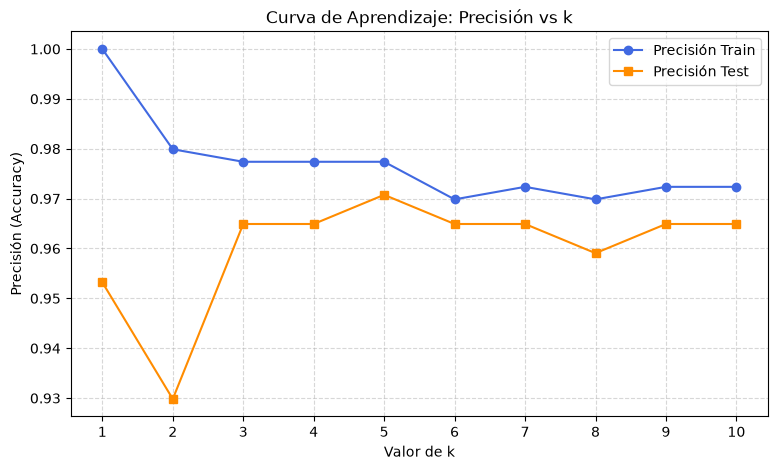

In [ ]:
acc_train = []
acc_test = []

for k in k_candidatos:
  mod = KNNClassifier(k=k, distance_metric="euclidean")
  mod.fit(X_train, y_train)

  preds_tr = mod.predict(X_train)
  acc_train.append(np.mean(preds_tr == y_train))

  preds_ts = mod.predict(X_test)
  acc_test.append(np.mean(preds_ts == y_test))

plt.figure(figsize=(9, 5))
plt.plot(
    k_candidatos,
    acc_train,
    label="Precisión Train",
    marker="o",
    color="royalblue",
)
plt.plot(
    k_candidatos,
    acc_test,
    label="Precisión Test",
    marker="s",
    color="darkorange",
)
plt.title("Curva de Aprendizaje")
plt.xlabel("Valor de k")
plt.xticks(k_candidatos)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

Ahora cambiemos la distanciap or Mikowski

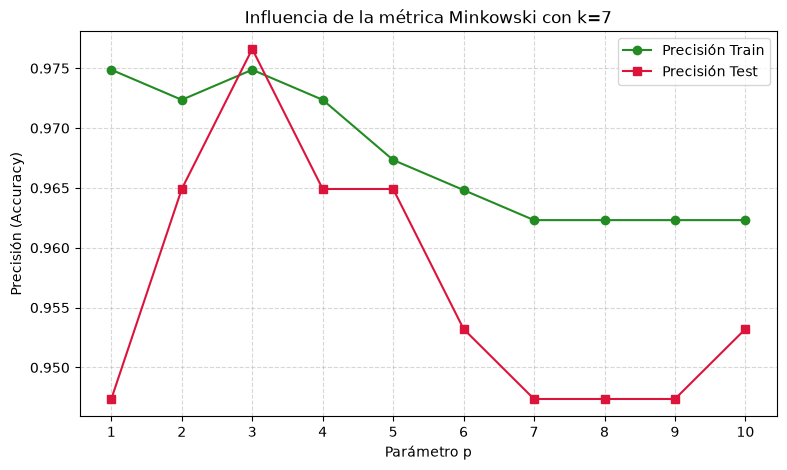

In [ ]:
p_valores = list(range(1, 11))
acc_p_train = []
acc_p_test = []

for p in p_valores:
  mod_p = KNNClassifier(k=mejor_k, distance_metric="minkowski", p=p)
  mod_p.fit(X_train, y_train)

  preds_tr = mod_p.predict(X_train)
  acc_p_train.append(np.mean(preds_tr == y_train))

  preds_ts = mod_p.predict(X_test)
  acc_p_test.append(np.mean(preds_ts == y_test))

plt.figure(figsize=(9, 5))
plt.plot(
    p_valores,
    acc_p_train,
    label="Precisión Train",
    marker="o",
    color="forestgreen",
)

plt.plot(
    p_valores, acc_p_test,
    label="Precisión Test",
    marker="s",
    color="crimson"
)
plt.title(f"Influencia de la métrica Minkowski con k={mejor_k}")
plt.xlabel("Parámetro p")
plt.ylabel("Precisión (Accuracy)")
plt.xticks(p_valores)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

##### *La distancia, y en este caso el parámetro $p$, son también hiperparámetros del modelo. ¿Sería necesario incluirlos en el proceso de validación cruzada?*

 Sí, es necesario. La distancia y el valor de $p$ son decisiones de diseño que no se aprenden durante el ajuste (fit). Si los evaluamos o elegimos mirando directamente el conjunto de test, provocaríamos sobreajuste al test (data leakage metodológico).   La forma correcta es realizar una búsqueda en rejilla (Grid Search) combinada con validación cruzada sobre el conjunto de entrenamiento, evaluando conjuntamente los pares $(k, p)$ para seleccionar la mejor combinación antes de tocar el test definitivo.   

# 4) Seleccion de Atributos

Seleccionamos la K optima del ejercicio anterior.

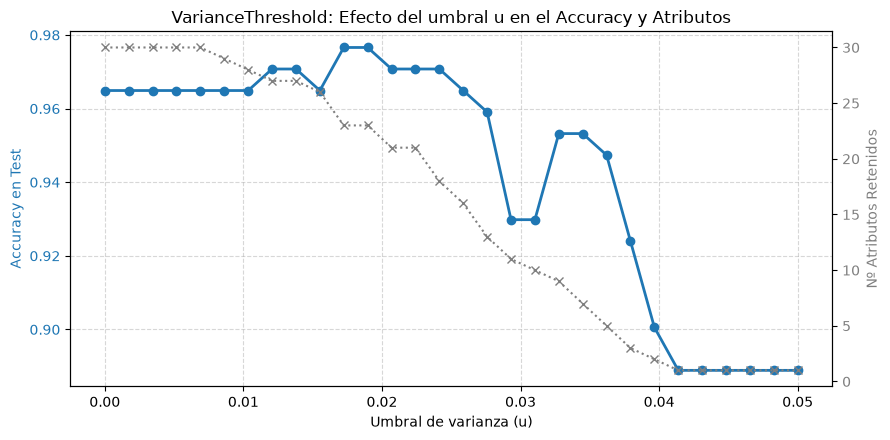

In [ ]:
umbrales = np.linspace(0.0, 0.05, 30)
acc_vt = []
n_feats_vt = []

for u in umbrales:
  vt = VarianceThreshold(threshold=u)
  X_tr_vt = vt.fit_transform(X_train)
  X_ts_vt = vt.transform(X_test)

  n_f = X_tr_vt.shape[1]
  n_feats_vt.append(n_f)

  if n_f > 0:
    clf = KNNClassifier(k=mejor_k, distance_metric="euclidean")
    clf.fit(X_tr_vt, y_train)
    preds = clf.predict(X_ts_vt)
    acc_vt.append(accuracy_score(y_test, preds))
    
  else:
    acc_vt.append(0.0)

fig, ax1 = plt.subplots(figsize=(9, 4.5))

color = "tab:blue"
ax1.set_xlabel("Umbral de varianza")
ax1.set_ylabel("Accuracy en Test", color=color)
ax1.plot(
    umbrales,
    acc_vt,
    color=color,
    marker="o",
    linewidth=2,
    label="Accuracy Test",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
color = "tab:gray"
ax2.set_ylabel("Nº Atributos Retenidos", color=color)
ax2.plot(
    umbrales,
    n_feats_vt,
    color=color,
    linestyle=":",
    marker="x",
    label="Nº Atributos",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("varianceThreshold")
fig.tight_layout()
plt.show()

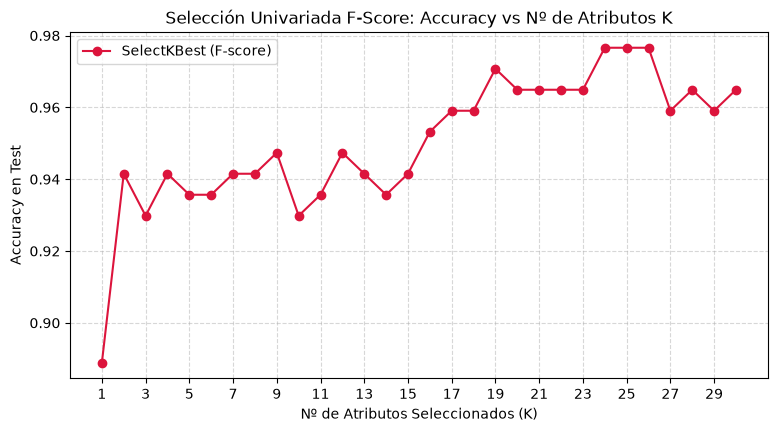

In [ ]:
n_total_features = X_train.shape[1]
k_features_range = list(range(1, n_total_features + 1))
acc_fscore = []

for K in k_features_range:
  skb = SelectKBest(score_func=f_classif, k=K)
  X_tr_f = skb.fit_transform(X_train, y_train)
  X_ts_f = skb.transform(X_test)

  clf = KNNClassifier(k=mejor_k, distance_metric="euclidean")
  clf.fit(X_tr_f, y_train)
  preds = clf.predict(X_ts_f)
  acc_fscore.append(accuracy_score(y_test, preds))

plt.figure(figsize=(9, 4.5))
plt.plot(
    k_features_range,
    acc_fscore,
    marker="o",
    color="crimson",
    label="SelectKBest (F-score)",
)
plt.title("Selección Univariada F-Score: Accuracy vs Nº de Atributos K")
plt.xlabel("Nº de Atributos Seleccionados (K)")
plt.ylabel("Accuracy en Test")
plt.xticks(np.arange(1, n_total_features + 1, 2))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

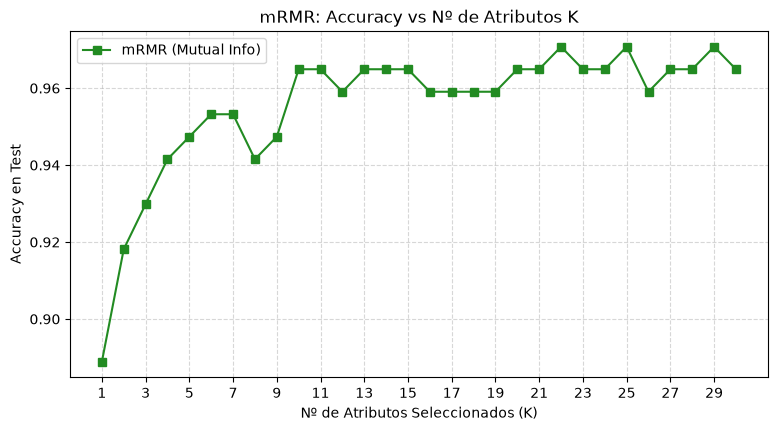

In [ ]:
n_bins = 10
X_train_binned = np.zeros_like(X_train, dtype=int)
for col in range(n_total_features):
    X_train_binned[:, col] = np.digitize(
        X_train[:, col], bins=np.linspace(0, 1, n_bins)
    )

selector_mrmr = mRMR(n_features=n_total_features)
selector_mrmr.fit(X_train_binned, y_train)
orden_mrmr = selector_mrmr.selected_indices_

acc_mrmr = []
for K in k_features_range:
    sub_indices = orden_mrmr[:K]
    X_tr_sub = X_train[:, sub_indices]
    X_ts_sub = X_test[:, sub_indices]

    clf = KNNClassifier(k=mejor_k, distance_metric="euclidean")
    clf.fit(X_tr_sub, y_train)
    preds = clf.predict(X_ts_sub)
    acc_mrmr.append(accuracy_score(y_test, preds))

plt.figure(figsize=(9, 4.5))
plt.plot(
    k_features_range,
    acc_mrmr,
    marker="s",
    color="forestgreen",
    label="mRMR (Mutual Info)",
)
plt.title("mRMR: Accuracy vs Nº de Atributos K")
plt.xlabel("Nº de Atributos Seleccionados (K)")
plt.ylabel("Accuracy en Test")
plt.xticks(np.arange(1, n_total_features + 1, 2))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

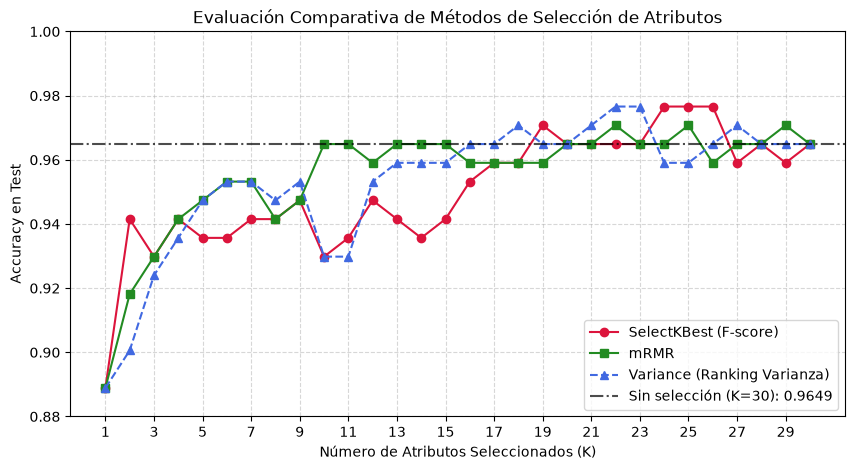

In [ ]:
varianzas = np.var(X_train, axis=0)
orden_varianza = np.argsort(varianzas)[::-1]

acc_vt = []
for K in k_features_range:
    sub_indices = orden_varianza[:K]
    X_tr_vt = X_train[:, sub_indices]
    X_ts_vt = X_test[:, sub_indices]
    
    clf = KNNClassifier(k=mejor_k, distance_metric="euclidean")
    clf.fit(X_tr_vt, y_train)
    acc_vt.append(accuracy_score(y_test, clf.predict(X_ts_vt)))

clf_full = KNNClassifier(k=mejor_k, distance_metric="euclidean")
clf_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test))

plt.figure(figsize=(10, 5))
plt.plot(k_features_range, acc_fscore, marker="o", color="crimson", label="SelectKBest (F-score)")
plt.plot(k_features_range, acc_mrmr, marker="s", color="forestgreen", label="mRMR")
plt.plot(k_features_range, acc_vt, marker="^", color="royalblue", linestyle="--", label="Variance (Ranking Varianza)")
plt.axhline(y=acc_full, color="black", linestyle="-.", alpha=0.7, label=f"Sin selección (K=30): {acc_full:.4f}")

plt.title("Métodos de Selección de Atributos")
plt.xlabel("Número de Atributos Seleccionados")
plt.ylabel("Accuracy en Test")
plt.xticks(np.arange(1, n_total_features + 1, 2))
plt.ylim([0.88, 1.0])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.show()